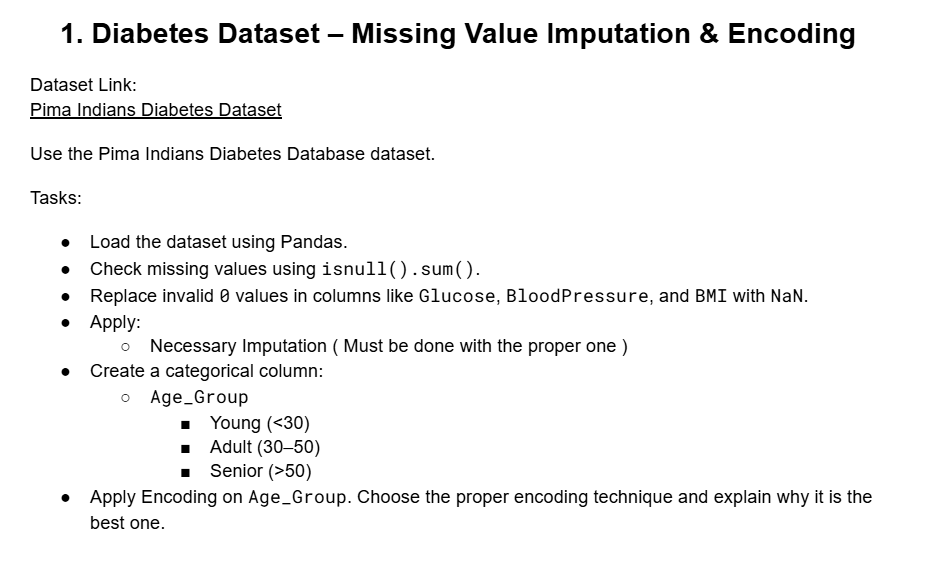

In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

In [3]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
imputer = SimpleImputer(strategy='mean')
df[cols] = imputer.fit_transform(df[cols])


In [10]:
df["Age_Group"] = np.where(df["Age"] < 30, "Young",np.where(df["Age"] <= 50, "Adult", "Senior"))

df[["Age", "Age_Group"]].head(10)

,Age,Age_Group
0,50,Adult
1,31,Adult
2,32,Adult
3,21,Young
4,33,Adult
5,30,Adult
6,26,Young
7,29,Young
8,53,Senior
9,54,Senior


In [9]:
encoder = OrdinalEncoder(categories=[["Young", "Adult", "Senior"]])

df["Age_Group_Encoded"] = encoder.fit_transform(df[["Age_Group"]])

df[["Age_Group", "Age_Group_Encoded"]].head()

,Age_Group,Age_Group_Encoded
0,Adult,1.0
1,Adult,1.0
2,Adult,1.0
3,Young,0.0
4,Adult,1.0


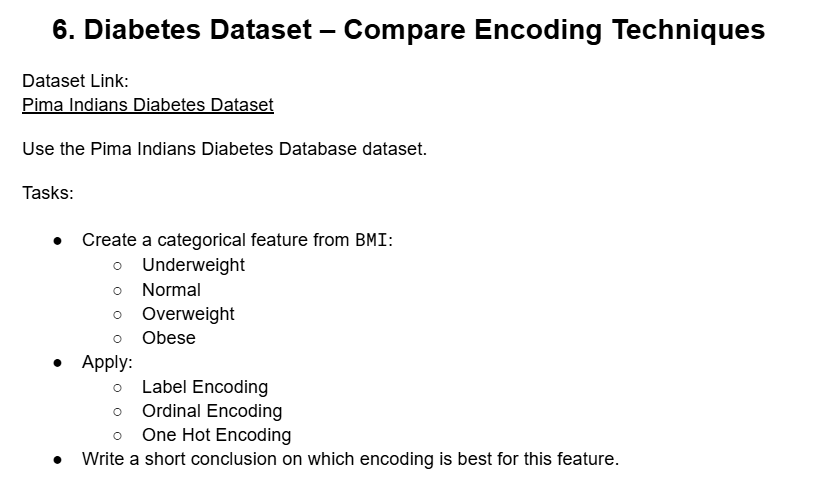